# E-Bike Demand Analysis Notebook

What's Actually in This Data?

Before jumping into tests and analysis, let's just get familiar with what we're working with.

**What I want to know:**
- How much data do we have?
- Are there missing values I need to deal with?
- What's the distribution of rentals look like?
- Any obvious patterns or weirdness?

This is basically the "look before you leap" step.

In [17]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime

In [18]:
# Loading the data
df = pd.read_csv('datasets/bike_sharing.csv')

print(f"Loaded {len(df):,} rows and {len(df.columns)} columns")
print(f"\nDate range: {df['datetime'].min()} to {df['datetime'].max()}")

Loaded 10,886 rows and 12 columns

Date range: 2011-01-01 00:00:00 to 2012-12-19 23:00:00


### Quick Overview

In [19]:
# What does this thing look like?
df.head(10)

,datetime,season,holiday,workingday,weather,temp,atemp,humidity,windspeed,casual,registered,count
0,2011-01-01 00:00:00,1,0,0,1,9.84,14.395,81,0.0000,3,13,16
1,2011-01-01 01:00:00,1,0,0,1,9.02,13.635,80,0.0000,8,32,40
2,2011-01-01 02:00:00,1,0,0,1,9.02,13.635,80,0.0000,5,27,32
3,2011-01-01 03:00:00,1,0,0,1,9.84,14.395,75,0.0000,3,10,13
4,2011-01-01 04:00:00,1,0,0,1,9.84,14.395,75,0.0000,0,1,1
5,2011-01-01 05:00:00,1,0,0,2,9.84,12.880,75,6.0032,0,1,1
6,2011-01-01 06:00:00,1,0,0,1,9.02,13.635,80,0.0000,2,0,2
7,2011-01-01 07:00:00,1,0,0,1,8.20,12.880,86,0.0000,1,2,3
8,2011-01-01 08:00:00,1,0,0,1,9.84,14.395,75,0.0000,1,7,8
9,2011-01-01 09:00:00,1,0,0,1,13.12,17.425,76,0.0000,8,6,14


In [20]:
# Data types and information
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10886 entries, 0 to 10885
Data columns (total 12 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   datetime    10886 non-null  object 
 1   season      10886 non-null  int64  
 2   holiday     10886 non-null  int64  
 3   workingday  10886 non-null  int64  
 4   weather     10886 non-null  int64  
 5   temp        10886 non-null  float64
 6   atemp       10886 non-null  float64
 7   humidity    10886 non-null  int64  
 8   windspeed   10886 non-null  float64
 9   casual      10886 non-null  int64  
 10  registered  10886 non-null  int64  
 11  count       10886 non-null  int64  
dtypes: float64(3), int64(8), object(1)
memory usage: 1020.7+ KB


In [21]:
# Basic stats for numeric columns
df.describe()

,season,holiday,workingday,weather,temp,atemp,humidity,windspeed,casual,registered,count
count,10886.000000,10886.000000,10886.000000,10886.000000,10886.00000,10886.000000,10886.000000,10886.000000,10886.000000,10886.000000,10886.000000
mean,2.506614,0.028569,0.680875,1.418427,20.23086,23.655084,61.886460,12.799395,36.021955,155.552177,191.574132
std,1.116174,0.166599,0.466159,0.633839,7.79159,8.474601,19.245033,8.164537,49.960477,151.039033,181.144454
min,1.000000,0.000000,0.000000,1.000000,0.82000,0.760000,0.000000,0.000000,0.000000,0.000000,1.000000
25%,2.000000,0.000000,0.000000,1.000000,13.94000,16.665000,47.000000,7.001500,4.000000,36.000000,42.000000
50%,3.000000,0.000000,1.000000,1.000000,20.50000,24.240000,62.000000,12.998000,17.000000,118.000000,145.000000
75%,4.000000,0.000000,1.000000,2.000000,26.24000,31.060000,77.000000,16.997900,49.000000,222.000000,284.000000
max,4.000000,1.000000,1.000000,4.000000,41.00000,45.455000,100.000000,56.996900,367.000000,886.000000,977.000000


## Missing Values Check

Nothing kills an analysis faster than not noticing missing data.

In [22]:
missing = df.isnull().sum()
print(missing)

datetime      0
season        0
holiday       0
workingday    0
weather       0
temp          0
atemp         0
humidity      0
windspeed     0
casual        0
registered    0
count         0
dtype: int64


In [23]:
if missing.sum() == 0:
    print("No missing values found")
else:
    print(f"Total missing: {missing.sum()}")

No missing values found


## What each variable means

- datetime - timestamp for each hour

- season - 1 spring, 2 summer, 3 fall, 4 winter

- holiday - 1 if holiday, 0 otherwise

- workingday - 1 if working day (not weekend or holiday), 0 otherwise

- weather - 1 clear, 2 mist/clouds, 3 light rain/snow, 4 heavy rain

- temp - temperature in Celsius

- atemp - feels like temperature in Celsius

- humidity - humidity percent

- windspeed - wind speed in km/h

- casual - number of bikes rented by casual users

- registered - number of bikes rented by registered users

- count - total bikes rented (our main variable)

## Look at categorical variables

In [24]:
print("Season:")
print(df['season'].value_counts().sort_index())
print()

print("Holiday:")
print(df['holiday'].value_counts().sort_index())
print()

print("Working day:")
print(df['workingday'].value_counts().sort_index())
print()

print("Weather:")
print(df['weather'].value_counts().sort_index())

Season:
season
1    2686
2    2733
3    2733
4    2734
Name: count, dtype: int64

Holiday:
holiday
0    10575
1      311
Name: count, dtype: int64

Working day:
workingday
0    3474
1    7412
Name: count, dtype: int64

Weather:
weather
1    7192
2    2834
3     859
4       1
Name: count, dtype: int64


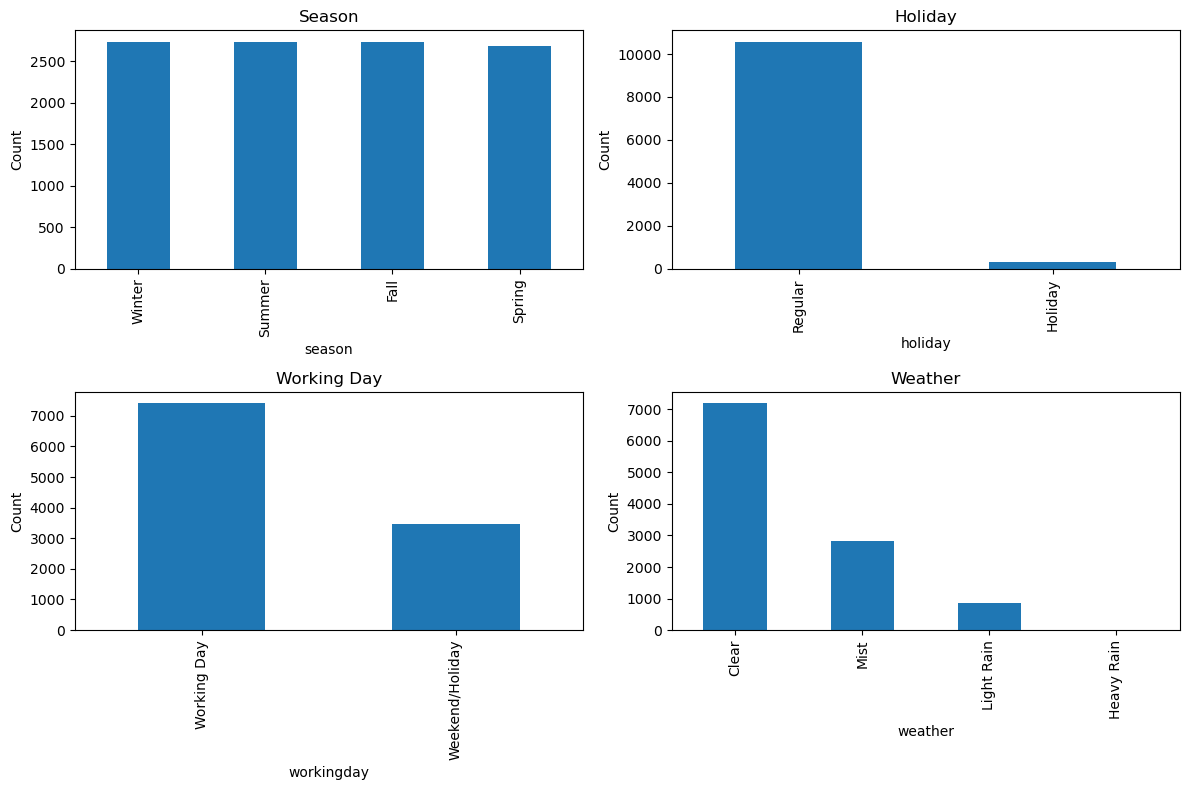

In [25]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8))

season_map = {1: 'Spring', 2: 'Summer', 3: 'Fall', 4: 'Winter'}
df['season'].map(season_map).value_counts().plot(kind='bar', ax=axes[0,0])
axes[0,0].set_title('Season')
axes[0,0].set_ylabel('Count')

holiday_map = {0: 'Regular', 1: 'Holiday'}
df['holiday'].map(holiday_map).value_counts().plot(kind='bar', ax=axes[0,1])
axes[0,1].set_title('Holiday')
axes[0,1].set_ylabel('Count')

working_map = {0: 'Weekend/Holiday', 1: 'Working Day'}
df['workingday'].map(working_map).value_counts().plot(kind='bar', ax=axes[1,0])
axes[1,0].set_title('Working Day')
axes[1,0].set_ylabel('Count')

weather_map = {1: 'Clear', 2: 'Mist', 3: 'Light Rain', 4: 'Heavy Rain'}
df['weather'].map(weather_map).value_counts().plot(kind='bar', ax=axes[1,1])
axes[1,1].set_title('Weather')
axes[1,1].set_ylabel('Count')

plt.tight_layout()
plt.show()

## Rental counts

In [26]:
print("Total rentals (count):")
print(f"Mean: {df['count'].mean():.1f}")
print(f"Median: {df['count'].median():.1f}")
print(f"Min: {df['count'].min()}")
print(f"Max: {df['count'].max()}")
print()

print("Casual vs Registered:")
total_casual = df['casual'].sum()
total_registered = df['registered'].sum()
total_all = df['count'].sum()

print(f"Casual: {total_casual:,}")
print(f"Registered: {total_registered:,}")
print(f"Registered percent: {total_registered/total_all*100:.1f}%")

Total rentals (count):
Mean: 191.6
Median: 145.0
Min: 1
Max: 977

Casual vs Registered:
Casual: 392,135
Registered: 1,693,341
Registered percent: 81.2%


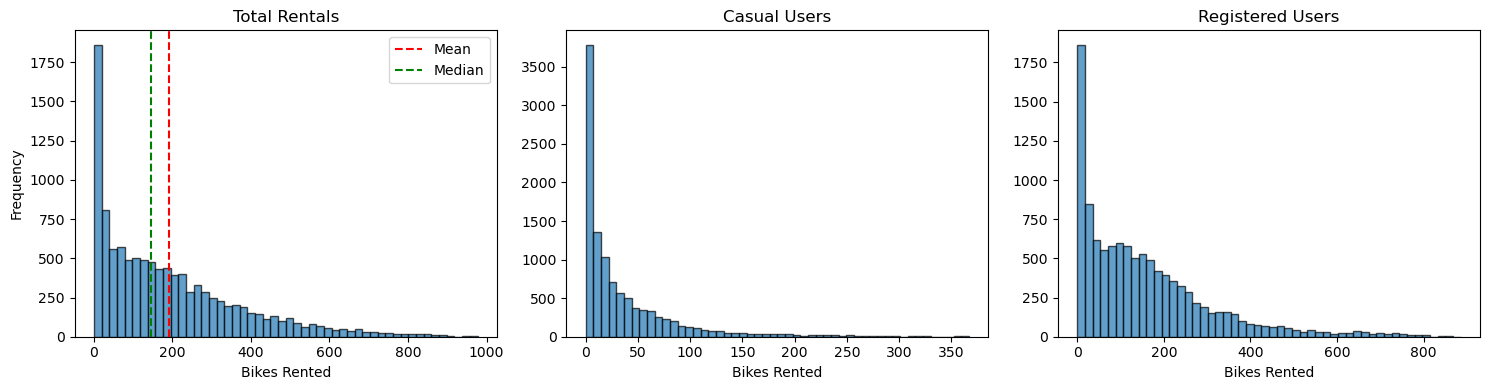

In [27]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].hist(df['count'], bins=50, edgecolor='black', alpha=0.7)
axes[0].set_title('Total Rentals')
axes[0].set_xlabel('Bikes Rented')
axes[0].set_ylabel('Frequency')
axes[0].axvline(df['count'].mean(), color='red', linestyle='--', label='Mean')
axes[0].axvline(df['count'].median(), color='green', linestyle='--', label='Median')
axes[0].legend()

axes[1].hist(df['casual'], bins=50, edgecolor='black', alpha=0.7)
axes[1].set_title('Casual Users')
axes[1].set_xlabel('Bikes Rented')

axes[2].hist(df['registered'], bins=50, edgecolor='black', alpha=0.7)
axes[2].set_title('Registered Users')
axes[2].set_xlabel('Bikes Rented')

plt.tight_layout()
plt.show()

## Weather variables

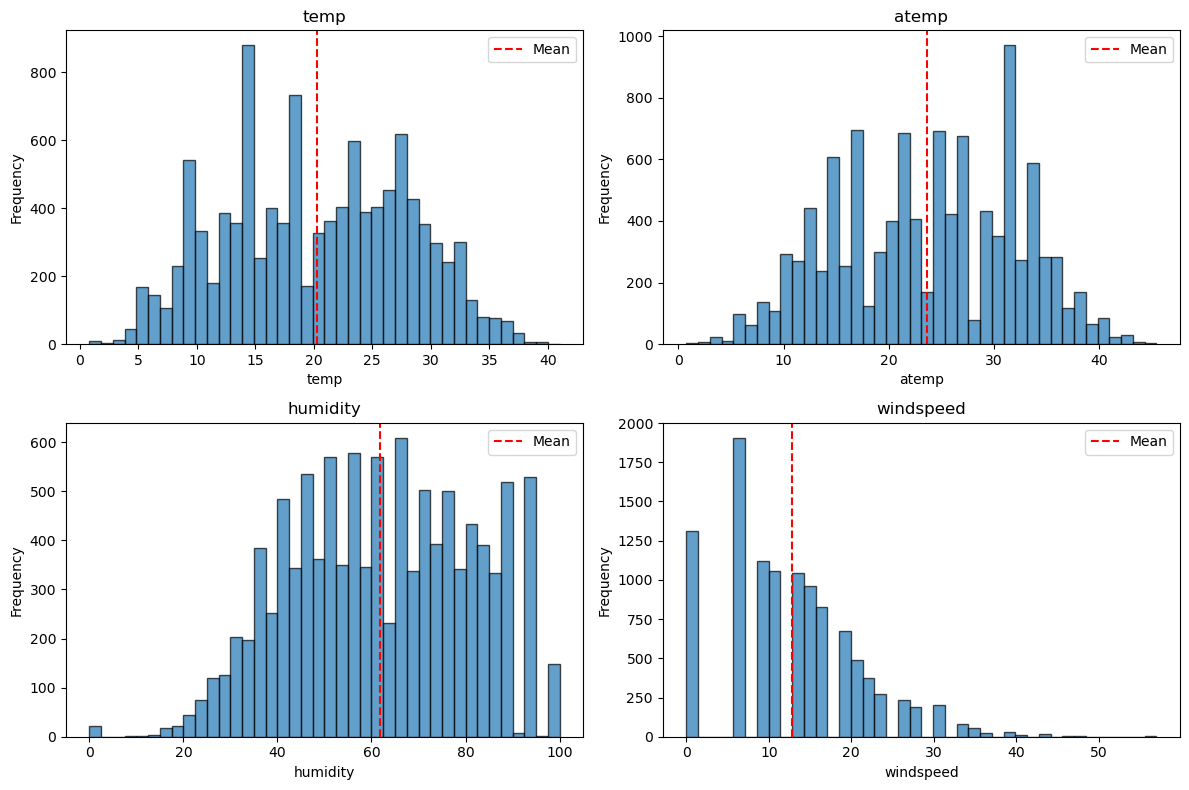

In [28]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
axes = axes.ravel()

weather_vars = ['temp', 'atemp', 'humidity', 'windspeed']

for i, var in enumerate(weather_vars):
    axes[i].hist(df[var], bins=40, edgecolor='black', alpha=0.7)
    axes[i].set_title(var)
    axes[i].set_xlabel(var)
    axes[i].set_ylabel('Frequency')
    axes[i].axvline(df[var].mean(), color='red', linestyle='--', label='Mean')
    axes[i].legend()

plt.tight_layout()
plt.show()

## Time patterns

Going to extract hour, day, month info to see patterns

In [29]:
df['datetime'] = pd.to_datetime(df['datetime'])

df['hour'] = df['datetime'].dt.hour
df['day'] = df['datetime'].dt.day
df['month'] = df['datetime'].dt.month
df['year'] = df['datetime'].dt.year
df['dayofweek'] = df['datetime'].dt.dayofweek

df[['datetime', 'hour', 'month', 'dayofweek']].head()

,datetime,hour,month,dayofweek
0,2011-01-01 00:00:00,0,1,5
1,2011-01-01 01:00:00,1,1,5
2,2011-01-01 02:00:00,2,1,5
3,2011-01-01 03:00:00,3,1,5
4,2011-01-01 04:00:00,4,1,5


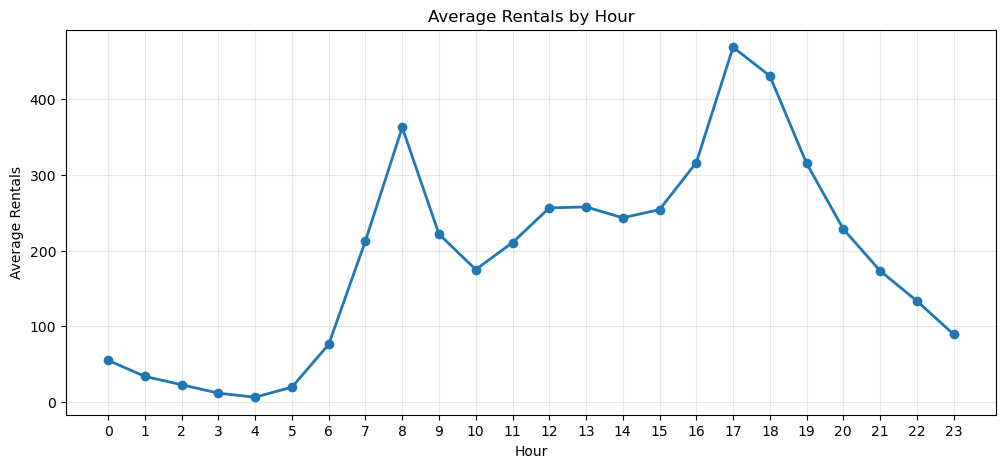

Peak hour: 17
Slowest hour: 4


In [30]:
hourly_avg = df.groupby('hour')['count'].mean()

plt.figure(figsize=(12, 5))
plt.plot(hourly_avg.index, hourly_avg.values, marker='o', linewidth=2)
plt.title('Average Rentals by Hour')
plt.xlabel('Hour')
plt.ylabel('Average Rentals')
plt.xticks(range(0, 24))
plt.grid(True, alpha=0.3)
plt.show()

print(f"Peak hour: {hourly_avg.idxmax()}")
print(f"Slowest hour: {hourly_avg.idxmin()}")

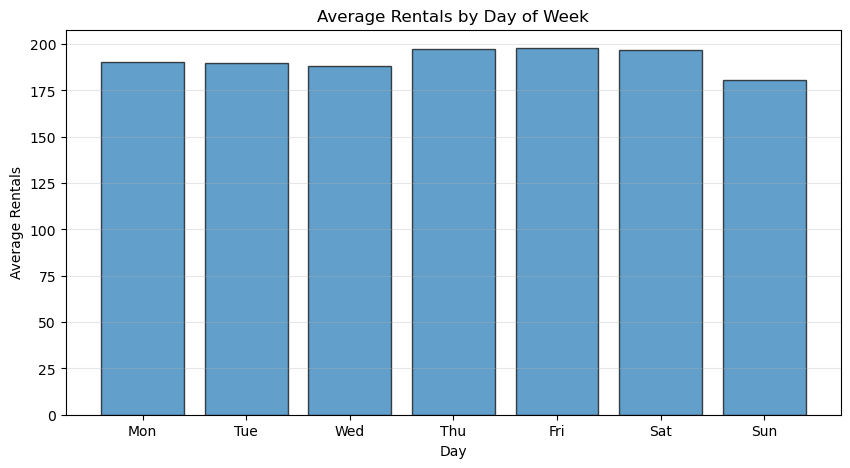

In [31]:
daily_avg = df.groupby('dayofweek')['count'].mean()
days = ['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun']

plt.figure(figsize=(10, 5))
plt.bar(range(7), daily_avg.values, edgecolor='black', alpha=0.7)
plt.title('Average Rentals by Day of Week')
plt.xlabel('Day')
plt.ylabel('Average Rentals')
plt.xticks(range(7), days)
plt.grid(True, alpha=0.3, axis='y')
plt.show()

## Correlation check

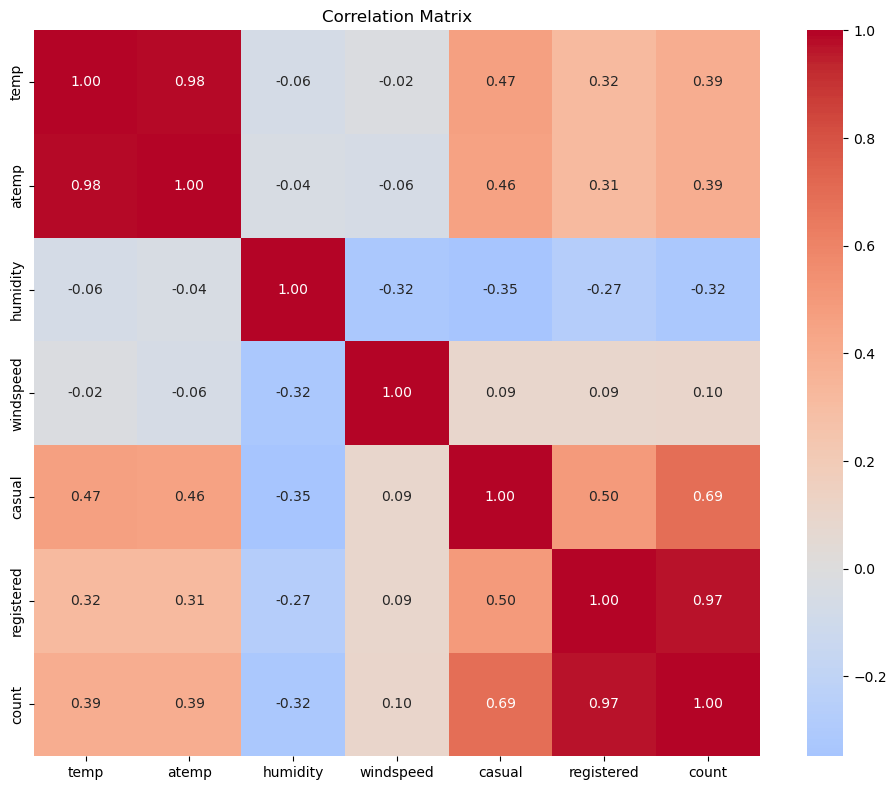

In [32]:
numeric_cols = ['temp', 'atemp', 'humidity', 'windspeed', 'casual', 'registered', 'count']
corr = df[numeric_cols].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0, square=True)
plt.title('Correlation Matrix')
plt.tight_layout()
plt.show()

In [33]:
print("Correlations with count:")
print(corr['count'].sort_values(ascending=False))

Correlations with count:
count         1.000000
registered    0.970948
casual        0.690414
temp          0.394454
atemp         0.389784
windspeed     0.101369
humidity     -0.317371
Name: count, dtype: float64


## What I noticed

Data is clean - no missing values, about 10,886 rows

Rentals are right-skewed. Most hours have moderate demand, few hours have very high demand

Registered users account for most rentals

Clear hourly pattern - peaks during commute times

Temperature positively correlated with rentals

Very few heavy rain observations (weather=4)

Need to check if weekdays vs weekends have different patterns

Should test if weather actually impacts demand significantly

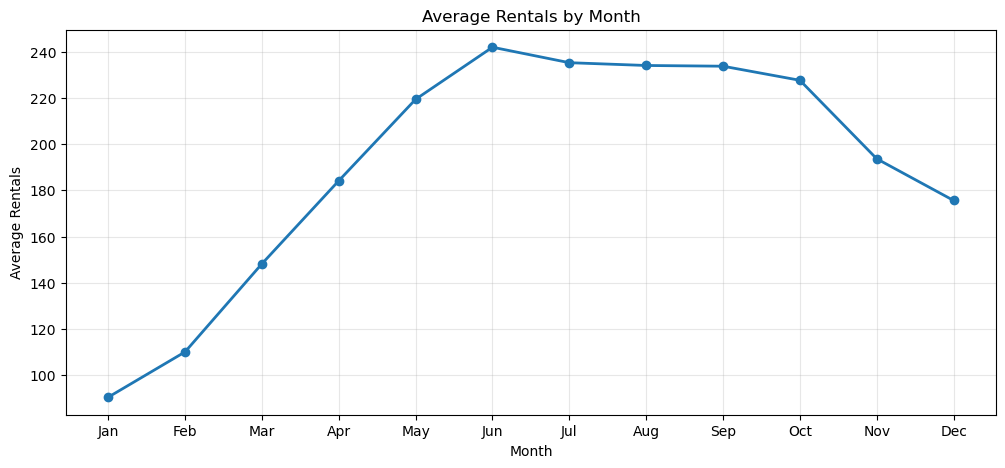

In [34]:
monthly_avg = df.groupby('month')['count'].mean()
months = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']

plt.figure(figsize=(12, 5))
plt.plot(monthly_avg.index, monthly_avg.values, marker='o', linewidth=2)
plt.title('Average Rentals by Month')
plt.xlabel('Month')
plt.ylabel('Average Rentals')
plt.xticks(range(1, 13), months)
plt.grid(True, alpha=0.3)
plt.show()